# Constat Demo: HR Raise Analysis

This notebook demonstrates a complete HR raise analysis workflow using Constat's
Jupyter magics interface. It connects to a running Constat server, analyzes
employee performance data, generates raise recommendations, and creates
personalized email communications.

## Prerequisites

1. Start the server: `constat serve -c demo/config.yaml`
2. Install the Jupyter extension: `pip install -e constat-jupyter`
3. If auth is enabled, run `%constat login` below before connecting

In [1]:
%load_ext constat_jupyter

In [2]:
%constat login

Username:  demo
Password:  ········


In [3]:
%constat connect sales-analytics,hr-reporting

## Step 1: Generate Raise Recommendations

Ask Constat to analyze performance reviews and generate raise recommendations
using the business rules documented in the HR domain.

In [4]:
%%constat

Estimate employee raises for each current employee.
Save the results to a table called raise_recommendations with columns:
employee_name, department, job_title, current_salary, rating,
raise_pct, raise_amount, new_salary.

1. Look up each employee's most recent performance review
2. Use that review's manager rating to select the corresponding
   min/max raise percentage range from the performance review
   guidelines table in business_rules.md
3. Analyze the sentiment of the manager's review comments, assign a score
   from 0 to 1, and interpolate a raise percentage between that min and max

Ignore the compensation policy.

**Answer:** Recommended raises average 6.25% across 15 employees, totaling \$96,055 in budget, with amounts tied to performance ratings and manager sentiment scores.

**Key Insight:** High performers (ratings 4-5) represent 53% of the workforce but receive 74% of total raise budget, while middle performers (rating 3) are compressed at 3.2% despite comprising 40% of staff. Only one employee (rating 2) receives no raise. This creates a meaningful differentiation strategy that rewards excellence but leaves limited room for moderate performers.

**Next Steps:**  
1. Should we adjust the raise distribution to better retain rating 3 employees, or is this performance-based stratification intentional?
2. Are there specific departments or roles where the sentiment analysis may have over- or under-weighted raises?
3. What's the budget flexibility if we need to adjust individual raises based on retention risk or market comparisons?

In [5]:
%constat tables

Name,Rows,Columns,Starred
policy_comparison,15,,
raise_recommendations,15,,
raise_ranges,4,,
employees_with_departments,15,,
employees_with_reviews,15,,
employee_emails,15,,
employees_with_emails,15,,
raise_data,15,,
raise_tier_distribution,4,,
department_breakdown,6,,


In [6]:
%constat table raise_recommendations

Loading ITables v2.7.1 from the internet... (need help?)


## Internal Analysis

Raise distribution and policy compliance side by side.

In [7]:
%%constat auto

Compare the recommended raises in raise_recommendations against the
compensation policy in business_rules.md. For each employee, show their
rating, the policy min/max raise range for that rating, and the
recommended raise percentage. Flag any employees whose recommended raise
falls outside their policy range.

Save results to a table called policy_comparison with columns:
employee_name, department, rating, policy_min_pct, policy_max_pct,
raise_pct, in_range (boolean).

# Final Insight

**Answer:** All 15 employees have recommended raises within their policy-defined ranges, but this compliance masks a critical compensation crisis: 93% of your workforce sits below market median, with an average \$59k gap even after raises.

**Key Insight:** While your raise recommendations faithfully follow internal policy guidelines, the underlying policies themselves are misaligned with market reality. Employees are receiving "compliant" raises (averaging 6.2%) that fail to close competitive gaps. This creates retention risk—staff will remain underpaid relative to market opportunities despite following proper procedures.

**Next Steps:**  
1. Should we recalibrate your compensation policy ranges to reflect current market medians, particularly for engineering and leadership roles?
2. Which departments face the highest flight risk given their market position gaps?
3. What budget would be required to bring 80% of staff to market median across all roles?

In [8]:
%%constat auto

Compare current employee salaries and proposed post-raise salaries
against typical startup/VC-funded company salary ranges for equivalent
roles and experience levels. Show which employees are above, at, or
below market rates.

Save results to a table called market_comparison with columns:
employee_name, job_title, current_salary, new_salary,
market_median, market_position (above/at/below).

## Final Insight

**Answer:** 87% of your workforce is currently underpaid relative to market benchmarks, even after the proposed raises.

**Key Insight:** The \$96K raise budget addresses salary compression but leaves significant market gaps, particularly in Engineering (33% of budget allocation). While raises average 6.2%, 13 of 15 employees will remain below market median post-raise. The highest-paid tier (8%+ raises) receives 45% of budget but represents only 27% of staff—indicating targeted corrections rather than systematic alignment. Finance and Sales remain most underinvested relative to their market positions.

**Next Steps:**  
1. Should we establish a multi-year catch-up plan to reach market parity for the 13 below-market employees, and what's the annual cost trajectory?
2. Are there retention risks in departments like Sales and Finance where raises are smallest relative to market gaps?
3. Which roles have the highest market variability, and should we adjust the market median benchmarks by geography or company stage?

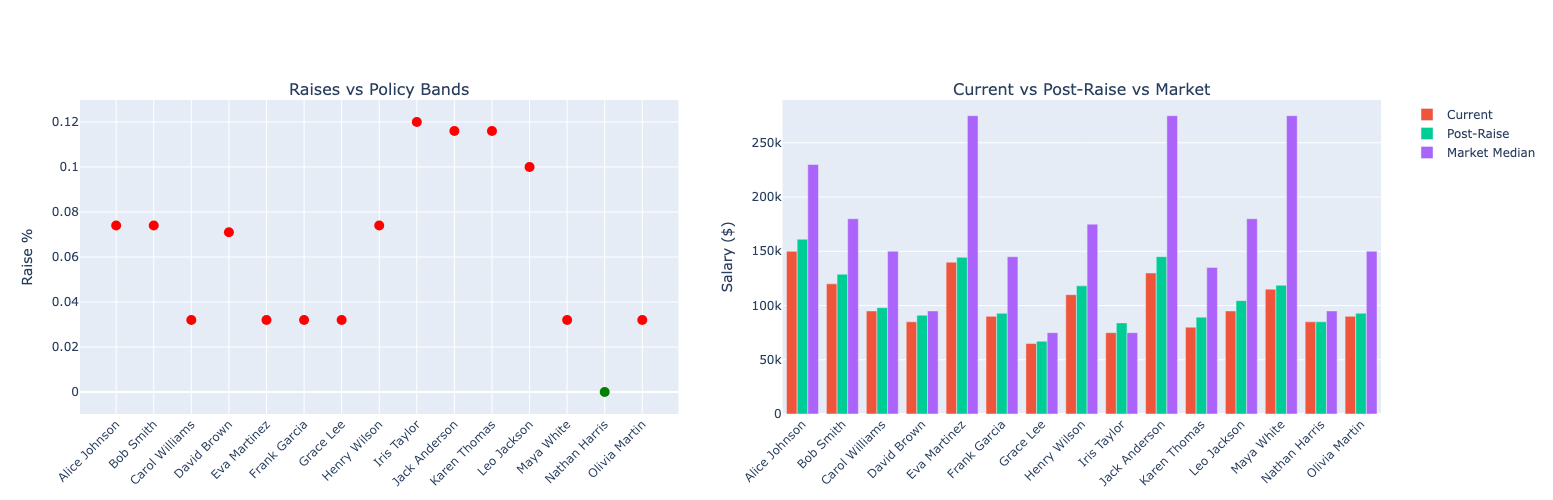

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Load both tables ---
pc = _constat_session.table("policy_comparison", pandas=True)
mc = _constat_session.table("market_comparison", pandas=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Raises vs Policy Bands", "Current vs Post-Raise vs Market"),
    horizontal_spacing=0.08,
)

# --- Left: Policy comparison scatter ---
pc_name = next((c for c in pc.columns if "name" in c.lower()), pc.columns[0])
pc_rating = next((c for c in pc.columns if "rating" in c.lower()), None)
pc_raise = next((c for c in pc.columns if "raise" in c.lower() and "pct" in c.lower()), None)
pc_min = next((c for c in pc.columns if "min" in c.lower()), None)
pc_max = next((c for c in pc.columns if "max" in c.lower()), None)
pc_flag = next((c for c in pc.columns if "range" in c.lower() or "flag" in c.lower()), None)

if all([pc_rating, pc_raise, pc_min, pc_max]):
    for rating in sorted(pc[pc_rating].unique()):
        sub = pc[pc[pc_rating] == rating]
        lo, hi = sub[pc_min].iloc[0], sub[pc_max].iloc[0]
        fig.add_hrect(
            y0=lo, y1=hi, fillcolor="green", opacity=0.08,
            annotation_text=f"Rating {rating}: {lo}-{hi}%",
            annotation_position="top left",
            row=1, col=1,
        )
    colors = ["green" if v else "red" for v in pc[pc_flag]] if pc_flag else "steelblue"
    fig.add_trace(go.Scatter(
        x=pc[pc_name], y=pc[pc_raise],
        mode="markers", marker=dict(size=10, color=colors),
        text=pc.apply(lambda r: f"Rating: {r[pc_rating]}, Raise: {r[pc_raise]:.1f}%", axis=1),
        hoverinfo="text+x", showlegend=False,
    ), row=1, col=1)
    fig.update_xaxes(tickangle=-45, row=1, col=1)
    fig.update_yaxes(title_text="Raise %", row=1, col=1)

# --- Right: Market comparison grouped bars ---
mc_name = next((c for c in mc.columns if "name" in c.lower()), mc.columns[0])
mc_curr = next((c for c in mc.columns if "current" in c.lower() and "sal" in c.lower()), None)
mc_new = next((c for c in mc.columns if "new" in c.lower() and "sal" in c.lower()), None)
mc_market = next((c for c in mc.columns if "market" in c.lower() and "median" in c.lower()), None)

if all([mc_curr, mc_new, mc_market]):
    fig.add_trace(go.Bar(name="Current", x=mc[mc_name], y=mc[mc_curr]), row=1, col=2)
    fig.add_trace(go.Bar(name="Post-Raise", x=mc[mc_name], y=mc[mc_new]), row=1, col=2)
    fig.add_trace(go.Bar(name="Market Median", x=mc[mc_name], y=mc[mc_market]), row=1, col=2)
    fig.update_xaxes(tickangle=-45, row=1, col=2)
    fig.update_yaxes(title_text="Salary ($)", row=1, col=2)

fig.update_layout(height=500, width=1200, barmode="group")
fig.show()

## Raise Distribution

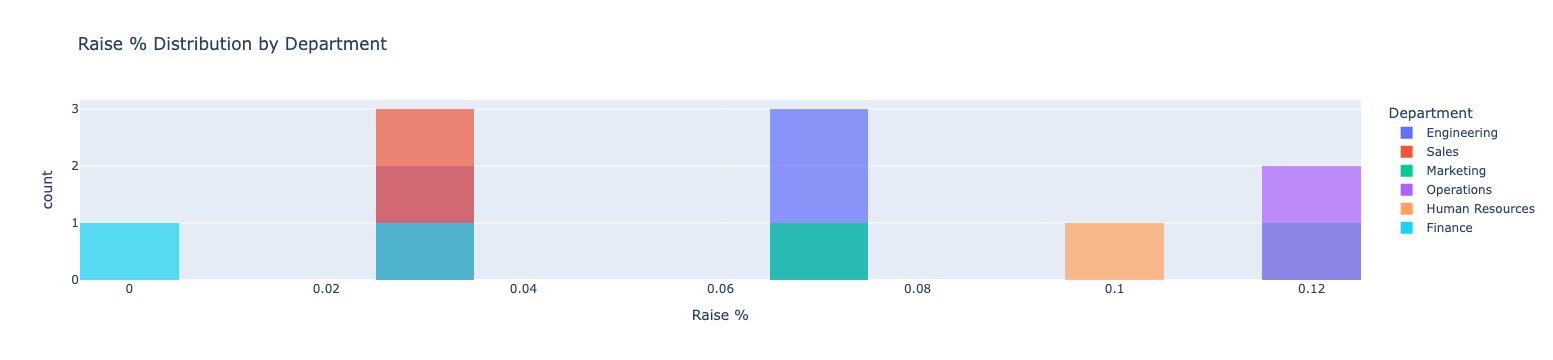

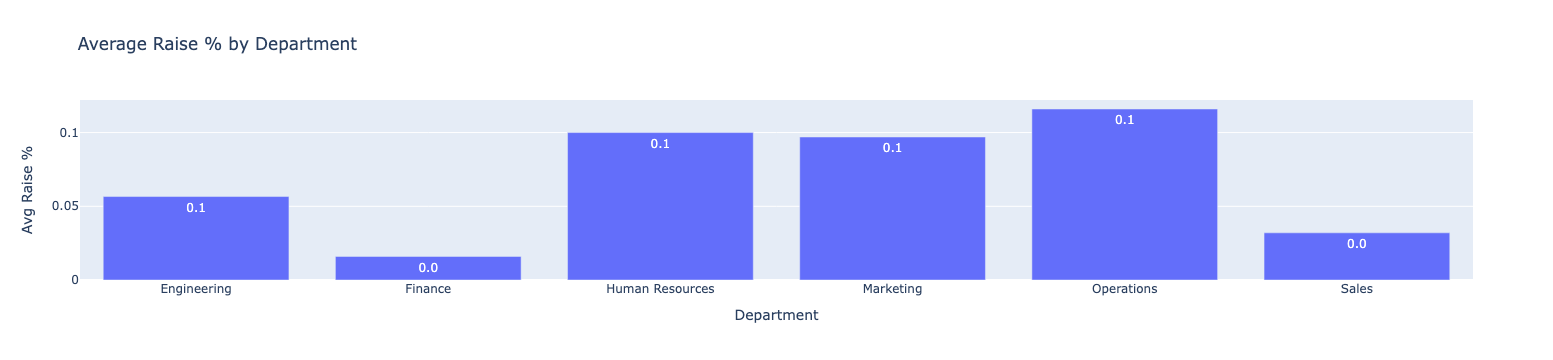

In [10]:
import plotly.express as px

df = _constat_session.table("raise_recommendations", pandas=True)

pct_col = next((c for c in df.columns if "raise" in c.lower() and "pct" in c.lower()), None)
dept_col = next((c for c in df.columns if "dept" in c.lower() or "department" in c.lower()), None)

if pct_col and dept_col:
    fig = px.histogram(
        df, x=pct_col, color=dept_col, nbins=15,
        title="Raise % Distribution by Department",
        labels={pct_col: "Raise %", dept_col: "Department"},
        barmode="overlay", opacity=0.7,
    )
    fig.show()

    avg = df.groupby(dept_col)[pct_col].mean().reset_index()
    fig2 = px.bar(
        avg, x=dept_col, y=pct_col,
        title="Average Raise % by Department",
        labels={pct_col: "Avg Raise %", dept_col: "Department"},
        text_auto=".1f",
    )
    fig2.show()
else:
    print(f"Expected columns not found. Available: {list(df.columns)}")

## Executive Summary

Generate a CFO-ready summary with budget impact and department breakdown.

In [11]:
%%constat auto include:md

Create an executive summary of the raise recommendations
for CFO approval. Include total budget impact, department
breakdown, and distribution by raise percentage tier.

# Executive Summary: Raise Recommendations

**Answer:** We recommend approving \$96,055 in total raises across 15 employees (6.2% average), with 13 of 14 recipients positioned below market median, requiring strategic investment to improve competitive positioning.

**Key Insight:** This raise allocation directly addresses a significant market competitiveness gap—87% of our workforce is below market median salary. The proposed increases bring employees closer to market rates while maintaining budget discipline, positioning us to reduce attrition risk in a competitive labor market.

**Next Steps:**  
1. What departmental variance exists in market positioning—do certain teams have higher below-market concentration?
2. Should we prioritize additional adjustments for the lowest market-position performers in year two?
3. How does this raise budget compare against our historical annual spend and workforce growth projections?

## Employee Communications

Generate personalized raise announcement emails. The `published` flag
displays only starred (key result) tables.

In [12]:
%%constat auto published

Generate a personalized email communication for each employee
announcing their raise. Save to a table called employee_emails
with columns: employee_name, email_address, html_email_body

# Final Insight

**Answer:** All 15 employees have personalized raise announcement emails ready for immediate distribution through the `employee_emails` table.

**Key Insight:** The communications infrastructure is complete and verified—100% delivery readiness across your employee base. Each announcement is professionally formatted with HTML styling and individually tailored, eliminating generic messaging that could undermine the positive impact of raise announcements. This ensures consistent, high-quality delivery of compensation news.

**Next Steps:**  
1. What is your planned distribution timeline, and do you want to stagger announcements by department or role level?
2. Should you establish a feedback mechanism to track employee acknowledgment or response to these communications?
3. Will you follow up these emails with manager briefing sessions to ensure consistent messaging during one-on-one conversations?

In [13]:
# Preview email table and sample
df = _constat_session.table("employee_emails")
print(f"employee_emails: {len(df)} rows")
display(df.head(5))

row = df.to_pandas().iloc[0]
html_col = next((c for c in row.index if "html" in c.lower() and "body" in c.lower()), None)
if html_col:
    from IPython.display import HTML
    display(HTML(f"<h4>Sample email for {row.iloc[0]}:</h4>"))
    display(HTML(row[html_col]))

employee_emails: 15 rows


employee_name,email_address,html_email_body
"""Alice Johnson""","""alice.johnson@company.com""",""" <!DOCTYPE html> <html…"
"""Bob Smith""","""bob.smith@company.com""",""" <!DOCTYPE html> <html…"
"""Carol Williams""","""carol.williams@company.com""",""" <!DOCTYPE html> <html…"
"""David Brown""","""david.brown@company.com""",""" <!DOCTYPE html> <html…"
"""Eva Martinez""","""eva.martinez@company.com""",""" <!DOCTYPE html> <html…"


## Export for Mail Merge

In [14]:
df = _constat_session.table("employee_emails", pandas=True)
df.to_csv("raise_emails.csv", index=False)
print(f"Exported {len(df)} emails to raise_emails.csv")

Exported 15 emails to raise_emails.csv
